In [56]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
from scipy import stats
import scanpy as sc
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
import anndata

intersted_genes = ['Gpr101','Pdyn','Trhr','Tacr3','Shox2']
markergenes = ['Dbh', 'Th', 'Slc6a2']

import trimesh
mesh_LC = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/LC_ccf_v1_250102 2.obj")
mesh_CD = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/subCD_ccf_v1_250102 2.obj")
mesh_CV = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/subCV_ccf_v1_250102 2.obj")
allmeshes = [mesh_LC,mesh_CD,mesh_CV]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [57]:
filename = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/data/adata_mer_subset_2_6k.h5ad'
adata_mer = sc.read_h5ad(filename)

In [58]:
umap_random_state = 307
sc.pp.neighbors(adata_mer, use_rep="X_scVI",  random_state=umap_random_state)
sc.tl.umap(adata_mer, random_state=210)
sc.tl.leiden(adata_mer, resolution=1,   key_added = 'new leiden!',random_state=umap_random_state)

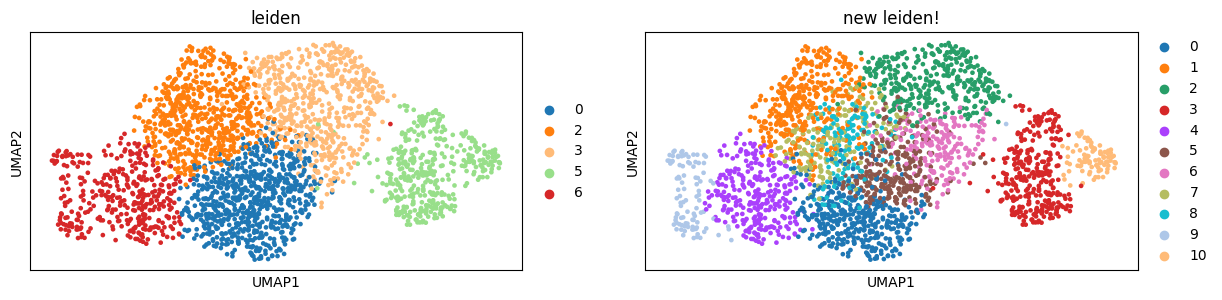

In [59]:
ax =sc.pl.umap(adata_mer, color=['leiden', 'new leiden!'], show = False)
for a in ax:
    a.set_aspect('equal')

In [60]:
dv_coords = adata_mer.obsm['spatial'][:,1].copy()
new_dv_coords = 2*(np.ptp(dv_coords)/2+dv_coords.min()) - dv_coords
adata_mer.obsm['spatial'][:,1] = new_dv_coords

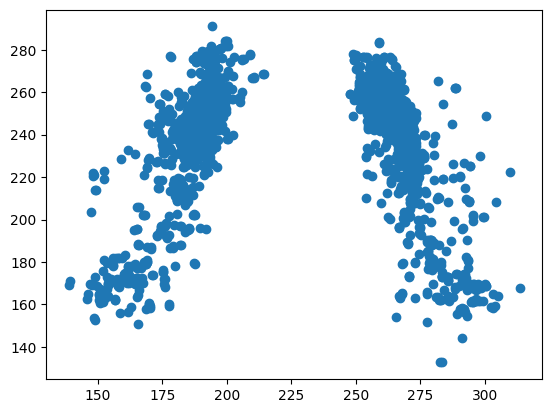

In [61]:
# plt.scatter(adata_mer.obsm['spatial'][:,2],new_dv_coords)
plt.scatter(adata_mer.obsm['spatial'][:,2],adata_mer.obsm['spatial'][:,1])

In [63]:
filename = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/data/adata_mer_subset_2_6k_for_cirrocumulus.h5ad'
adata_mer.write(filename)
